# View Ray Tracer Output

Load and display ray tracer images — either PGM (P5 binary) files or the
`"image"` array embedded in HDF5 field snapshots.

Set `DATA_ROOT` below to point to your ray tracer output directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
import re

In [2]:
# ============================================================
#  Path setup — same pattern as AJ_analysis
# ============================================================
# The ray tracer writes into output_dir (default "Data/") under
# the Aperture4 root.  Adjust this to point at your run directory.
DATA_ROOT = Path(
    "/data/RIS/cyuran/Active/giantflares/Aaron/Aperture4"
)

# ============================================================
#  PGM (P5 binary) helpers
# ============================================================
def read_pgm_p5(filepath):
    """Read a P5 (binary) PGM file → (width, height, maxval, pixels)."""
    with open(filepath, "rb") as f:
        header = f.readline().strip()
        if header != b"P5":
            raise ValueError(f"Not a P5 PGM file: {header}")
        line = f.readline()
        while line.startswith(b"#"):
            line = f.readline()
        width, height = map(int, line.split())
        maxval = int(f.readline().strip())
        dtype = np.uint8 if maxval < 256 else np.uint16
        pixels = np.frombuffer(f.read(), dtype=dtype)
        return width, height, maxval, pixels.reshape((height, width))


def find_pgm_files(data_dir, pattern="rt_image_*.pgm"):
    """Glob PGM files, sorted by embedded step number."""
    data_dir = Path(data_dir)
    return sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )


# ============================================================
#  HDF5 snapshot helper — "image" is saved with field data
# ============================================================
def get_image_h5(filepath, dataset_name="image", base_dir=DATA_ROOT):
    """
    Read the 2-D ``image`` array from an HDF5 field snapshot.

    Parameters
    ----------
    filepath : str or Path
        Relative or absolute path, e.g. ``"Data/fld.00005.h5"``.
    dataset_name : str
        Dataset name inside the HDF5 file (default ``"image"``).
    base_dir : Path
        Prepended when *filepath* is relative.
    """
    base_dir = Path(base_dir)
    filepath = Path(filepath)
    resolved = filepath if filepath.is_absolute() else base_dir / filepath

    with h5py.File(resolved, "r") as f:
        if dataset_name not in f:
            available = sorted(f.keys())
            raise KeyError(
                f"'{dataset_name}' not found in {resolved.name}. "
                f"Available: {available}"
            )
        img = np.asarray(f[dataset_name])
        # HDF5 data is (y, x) from Fortran-ordered write; transpose to (x, y)
        print(f"✓ '{dataset_name}' from {resolved.name}  shape={img.shape}")
        return img.T


def find_image_h5(data_dir, pattern="fld.*.h5", dataset_name="image"):
    """Find HDF5 field snapshots that contain ``dataset_name``."""
    data_dir = Path(data_dir)
    files = sorted(
        data_dir.glob(pattern),
        key=lambda p: int(re.search(r"(\d+)", p.stem).group()),
    )
    valid = []
    for p in files:
        try:
            with h5py.File(p, "r") as f:
                if dataset_name in f:
                    valid.append(p)
        except Exception:
            pass
    return valid

### Discover available images

This tries the PGM directory first, then falls back to HDF5 snapshots.

In [3]:
# --- Choose your data source ---
#  All output (PGM, fld.*.h5, ptc.*.h5) is now written to the same
#  subdirectory under DATA_ROOT by default.
pgm_dir = DATA_ROOT / "problems/ray_tracing/bin/Data"
h5_dir  = DATA_ROOT / "problems/ray_tracing/bin/Data"
ptc_dir = DATA_ROOT / "problems/ray_tracing/bin/Data"

use_pgm = True   # set False to read from HDF5 snapshots instead

if use_pgm:
    files = find_pgm_files(pgm_dir, "rt_image_*.pgm")
    print(f"Found {len(files)} PGM file(s) in {pgm_dir}:")
    for f in files:
        w, h, maxval, _ = read_pgm_p5(str(f))
        print(f"  {f.name}  ({w}x{h}, maxval={maxval})")
else:
    files = find_image_h5(h5_dir, "fld.*.h5", "image")
    print(f"Found {len(files)} HDF5 snapshot(s) with 'image' in {h5_dir}:")
    for f in files:
        print(f"  {f.name}")

# Sanity-check where ptc files really are
print(f"\nLooking for ptc.*.h5 in {ptc_dir} …")
if ptc_dir.exists():
    found = sorted(ptc_dir.glob("ptc.*.h5"))
    print(f"  → found {len(found)} file(s)")
    for p in found:
        print(f"      {p.name}")
else:
    print(f"  → directory does not exist!")


Found 41 PGM file(s) in /data/RIS/cyuran/Active/giantflares/Aaron/Aperture4/problems/ray_tracing/bin/Data:
  rt_image_0.pgm  (128x128, maxval=255)
  rt_image_5.pgm  (128x128, maxval=255)
  rt_image_10.pgm  (128x128, maxval=255)
  rt_image_15.pgm  (128x128, maxval=255)
  rt_image_20.pgm  (128x128, maxval=255)
  rt_image_25.pgm  (128x128, maxval=255)
  rt_image_30.pgm  (128x128, maxval=255)
  rt_image_35.pgm  (128x128, maxval=255)
  rt_image_40.pgm  (128x128, maxval=255)
  rt_image_45.pgm  (128x128, maxval=255)
  rt_image_50.pgm  (128x128, maxval=255)
  rt_image_55.pgm  (128x128, maxval=255)
  rt_image_60.pgm  (128x128, maxval=255)
  rt_image_65.pgm  (128x128, maxval=255)
  rt_image_70.pgm  (128x128, maxval=255)
  rt_image_75.pgm  (128x128, maxval=255)
  rt_image_80.pgm  (128x128, maxval=255)
  rt_image_85.pgm  (128x128, maxval=255)
  rt_image_90.pgm  (128x128, maxval=255)
  rt_image_95.pgm  (128x128, maxval=255)
  rt_image_100.pgm  (128x128, maxval=255)
  rt_image_105.pgm  (128x128, max

### View a single frame

Set `index` to choose which frame (0 = first, -1 = last).

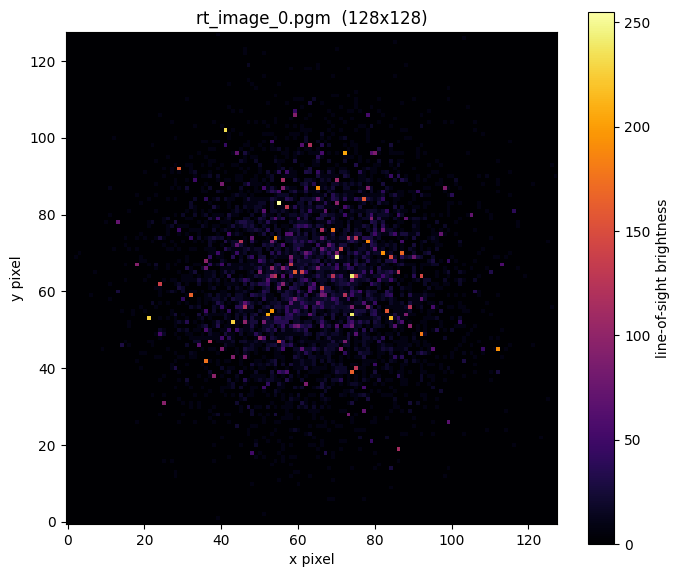

In [4]:
index = 0  # change to view different frames (0 = first, -1 = last)

if use_pgm:
    filepath = files[index]
    w, h, maxval, img = read_pgm_p5(str(filepath))
    title = f"{filepath.name}  ({w}x{h})"
else:
    filepath = files[index]
    img = get_image_h5(filepath, base_dir=".")   # files already absolute
    w, h = img.shape
    title = f"{filepath.name}  ({w}x{h})"

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(img.T if use_pgm else img, origin="lower",
               cmap="inferno", aspect="equal")
ax.set_title(title)
ax.set_xlabel("x pixel"); ax.set_ylabel("y pixel")
plt.colorbar(im, ax=ax, label="line-of-sight brightness")
plt.tight_layout()
plt.show()

### Movie — all frames

Collect every frame, normalize with a common color scale, and export an MP4
movie.  Requires `ffmpeg` on your `$PATH` (Matplotlib uses it as the writer).


In [5]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize

# ============================================================
# 1.  Load every frame into a list — same logic as the
#     single-frame viewer (PGM or HDF5).
# ============================================================
imgs = []
for i, fp in enumerate(files):
    if use_pgm:
        _, _, _, img = read_pgm_p5(str(fp))
    else:
        img = get_image_h5(fp, base_dir=".")
    imgs.append(img.T if use_pgm else img)

print(f"Loaded {len(imgs)} frames")

# ============================================================
# 2.  Global min / max so the color scale is consistent across
#     all frames.
# ============================================================
flat_imgs = np.concatenate([img.ravel() for img in imgs])
vmin = float(np.percentile(flat_imgs, 1))   # clip bottom 1 %
vmax = float(np.percentile(flat_imgs, 99))  # clip top 1 %
norm = Normalize(vmin=vmin, vmax=vmax)

# ============================================================
# 3.  Build the animation
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(imgs[0], origin="lower", cmap="inferno", norm=norm,
               aspect="equal")
cbar = plt.colorbar(im, ax=ax, label="line-of-sight brightness")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
title = ax.set_title("")

def animate(frame_idx):
    im.set_data(imgs[frame_idx])
    # extract step number from filename for the title
    stem = files[frame_idx].stem           # e.g. "rt_image_5" or "fld.00005"
    step = re.search(r"(\d+)", stem).group()
    title.set_text(f"step {step}")
    return [im, title]

ani = FuncAnimation(fig, animate, frames=len(imgs), interval=150, blit=True)

# ============================================================
# 4.  Write MP4 to the notebook’s own directory
# ============================================================
out_path = Path("ray_tracer_movie.mp4")   # saved next to this notebook
print(f"Writing {out_path.resolve()} …")
writer = FFMpegWriter(fps=8, bitrate=2000)
ani.save(str(out_path), writer=writer)
print(f"Done → {out_path.resolve()}")

plt.close(fig)


Loaded 41 frames
Writing /home/aaron/Research/Aperture4/problems/ray_tracing/ray_tracer_movie.mp4 …
Done → /home/aaron/Research/Aperture4/problems/ray_tracing/ray_tracer_movie.mp4


### 3D Particle Positions — camera view

Scatter plot of **tracked** particle $(x,y)$ positions, colored by $z$, from a
`ptc.*.h5` file.  Uses the same top-down perspective as the ray tracer camera
(observer at $+z$, looking back along $-z$).

All injected particles carry the `tracked` flag and are gathered by
`gather_tracked_ptc` into `ptc.*.h5` as `tracked_ptc_x1/x2/x3`.

Pick a snapshot below; all tracked particles in that file are shown.

In [6]:
# ============================================================
#  Load tracked particle positions from a single snapshot
# ============================================================
ptc_files = sorted(h5_dir.glob("ptc.*.h5"))
use_ptc = len(ptc_files) > 0
snapshot = ptc_files[0] if use_ptc else (sorted(h5_dir.glob("fld.*.h5"))[0])
print(f"Using {snapshot.name}  (source: {'ptc' if use_ptc else 'fld'})")

with h5py.File(snapshot, "r") as f:
    keys = sorted(f.keys())
    if use_ptc:
        has_x1 = "tracked_ptc_x1" in f
        has_x2 = "tracked_ptc_x2" in f
        has_x3 = "tracked_ptc_x3" in f
        x_name, y_name, z_name = "tracked_ptc_x1", "tracked_ptc_x2", "tracked_ptc_x3"
    else:
        has_x1 = "particles_x1" in f
        has_x2 = "particles_x2" in f
        has_x3 = "particles_x3" in f
        x_name, y_name, z_name = "particles_x1", "particles_x2", "particles_x3"

    if not (has_x1 and has_x2 and has_x3):
        print("Particle position datasets not found by that name.")
        print(f"Available datasets ({len(keys)} total):")
        for k in keys:
            print(f"  {k}   {f[k].shape if hasattr(f[k], 'shape') else 'scalar'}")
    else:
        x = np.asarray(f[x_name])
        y = np.asarray(f[y_name])
        z = np.asarray(f[z_name])
        print(f"Read {len(x)} particle positions from {snapshot.name}")
        print(f"  x range: [{x.min():.3f}, {x.max():.3f}]")
        print(f"  y range: [{y.min():.3f}, {y.max():.3f}]")
        print(f"  z range: [{z.min():.3f}, {z.max():.3f}]")


Using ptc.00000.h5  (source: ptc)
Read 9971 particle positions from ptc.00000.h5
  x range: [0.101, 10.000]
  y range: [0.058, 9.982]
  z range: [0.123, 9.963]


### 3D rotatable particle positions

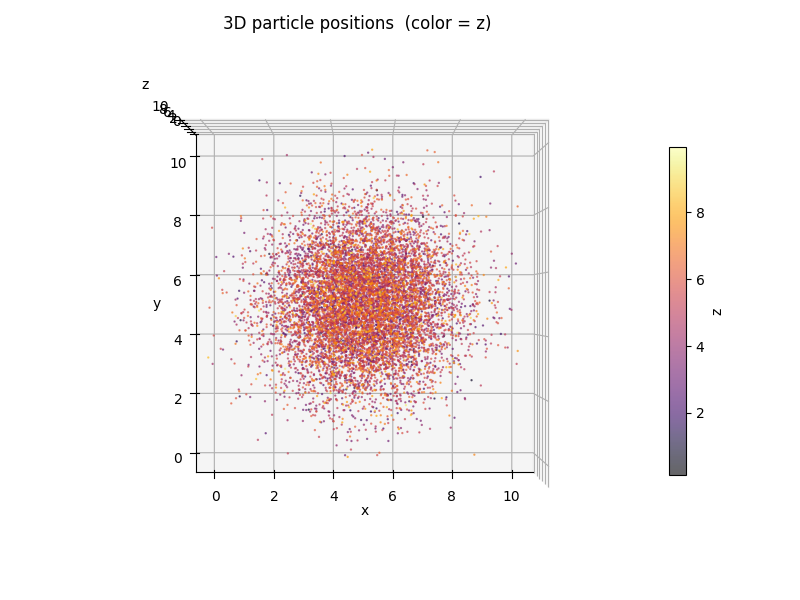

In [ ]:
# Use the interactive widget backend so the 3D plot can be rotated in-place.
%matplotlib widget

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig_3d = plt.figure(figsize=(8, 6))
ax_xyz = fig_3d.add_subplot(111, projection='3d')
sc3 = ax_xyz.scatter(x, y, z, c=z, s=0.5, cmap="inferno", alpha=0.6)
ax_xyz.set_title("3D particle positions  (color = z)")
ax_xyz.set_xlabel("x")
ax_xyz.set_ylabel("y")
ax_xyz.set_zlabel("z")
plt.colorbar(sc3, ax=ax_xyz, label="z", shrink=0.6)
# Set the view to match the camera: look down along -z
ax_xyz.view_init(elev=90, azim=-90)
plt.tight_layout()
plt.show()


### Camera view (2D top-down projection)

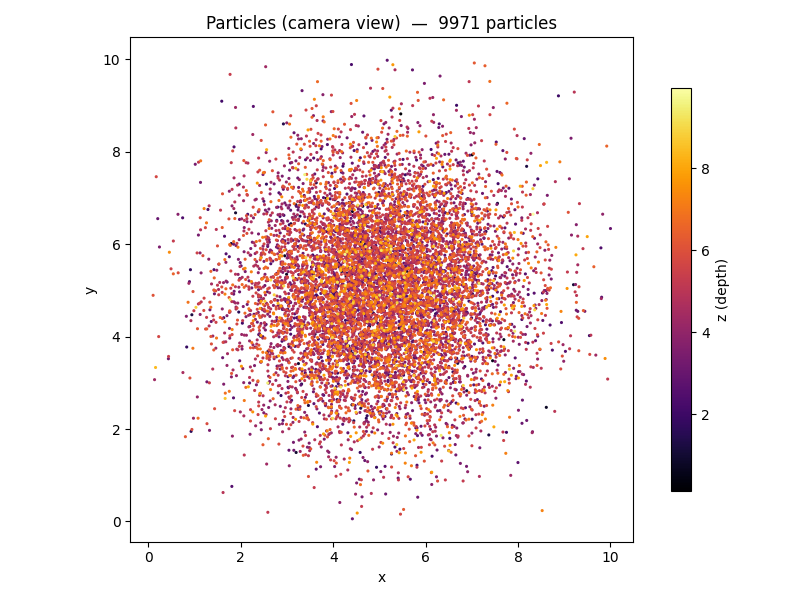

In [8]:
fig_2d, ax_xy = plt.subplots(figsize=(8, 6))
sc2 = ax_xy.scatter(x, y, c=z, s=5.0, cmap="inferno", edgecolors="none")
ax_xy.set_title(f"Particles (camera view)  —  {len(x)} particles")
ax_xy.set_xlabel("x")
ax_xy.set_ylabel("y")
ax_xy.set_aspect("equal")
plt.colorbar(sc2, ax=ax_xy, label="z (depth)", shrink=0.8)
plt.tight_layout()
plt.show()


### Side-by-side video: ray-tracer image vs. particle positions

Build a frame-by-frame MP4 that places the ray-tracer brightness image next to
the camera-view scatter plot so you can compare what the ray tracer "sees" with
the actual particle distribution at each output step.

**Requirements:**
- `ptc.*.h5` files exist and contain `tracked_ptc_x1/x2/x3` (or `particles_x1/x2/x3`).
- `fld.*.h5` files exist and contain the `"image"` dataset (used as the ray-tracer frame).
- `ffmpeg` on your `$PATH` (Matplotlib’s `FFMpegWriter`).

The two data sources are matched by sorting filenames and pairing by index.

In [12]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize

# ------------------------------------------------------------------
# 1.  Find matched pairs of fld (image) and ptc (particles) files
# ------------------------------------------------------------------
fld_files = find_image_h5(h5_dir, "fld.*.h5", "image")
ptc_files = sorted(h5_dir.glob("ptc.*.h5"))

if len(fld_files) == 0:
    print("No fld.*.h5 files with 'image' found — cannot build comparison video.")
elif len(ptc_files) == 0:
    print("No ptc.*.h5 files found — cannot build comparison video.")
else:
    # Pair by sorted order (both should correspond to the same output steps)
    n_frames = min(len(fld_files), len(ptc_files))
    print(f"Building comparison video with {n_frames} frame(s) …")

    # ------------------------------------------------------------------
    # 2.  Pre-load every frame + compute global limits
    # ------------------------------------------------------------------
    frames_img = []
    frames_ptc = []
    for i in range(n_frames):
        # --- ray-tracer image ---
        img = get_image_h5(fld_files[i], base_dir=".")
        frames_img.append(img)

        # --- particle positions ---
        with h5py.File(ptc_files[i], "r") as f:
            ptc_x = np.asarray(f["tracked_ptc_x1" if "tracked_ptc_x1" in f else "particles_x1"])
            ptc_y = np.asarray(f["tracked_ptc_x2" if "tracked_ptc_x2" in f else "particles_x2"])
            ptc_z = np.asarray(f["tracked_ptc_x3" if "tracked_ptc_x3" in f else "particles_x3"])
        frames_ptc.append((ptc_x, ptc_y, ptc_z))

    # Global image normalization (across all fld frames)
    flat = np.concatenate([im.ravel() for im in frames_img])
    img_vmin = float(np.percentile(flat, 1))
    img_vmax = float(np.percentile(flat, 99))
    img_norm = Normalize(vmin=img_vmin, vmax=img_vmax)

    # Global z-depth normalization (across all ptc frames)
    all_z = np.concatenate([fr[2] for fr in frames_ptc])
    z_vmin, z_vmax = float(all_z.min()), float(all_z.max())

    # ------------------------------------------------------------------
    # 3.  Build the side-by-side animation
    # ------------------------------------------------------------------
    fig_cmp, (ax_img, ax_ptc) = plt.subplots(1, 2, figsize=(14, 6))

    im_plot = ax_img.imshow(frames_img[0], origin="lower", cmap="inferno",
                            norm=img_norm, aspect="equal")
    ax_img.set_title("Ray-tracer image")
    ax_img.set_xlabel("x pixel")
    ax_img.set_ylabel("y pixel")
    plt.colorbar(im_plot, ax=ax_img, label="brightness", shrink=0.8)

    sc_plot = ax_ptc.scatter(frames_ptc[0][0], frames_ptc[0][1],
                             c=frames_ptc[0][2], s=5.0, cmap="inferno",
                             vmin=z_vmin, vmax=z_vmax, edgecolors="none")
    ax_ptc.set_title("Particle positions (camera view)")
    ax_ptc.set_xlabel("x")
    ax_ptc.set_ylabel("y")
    ax_ptc.set_aspect("equal")
    plt.colorbar(sc_plot, ax=ax_ptc, label="z (depth)", shrink=0.8)

    title_cmp = fig_cmp.suptitle("")

    def animate_cmp(idx):
        im_plot.set_data(frames_img[idx])
        sc_plot.set_offsets(np.column_stack((frames_ptc[idx][0], frames_ptc[idx][1])))
        sc_plot.set_array(frames_ptc[idx][2])
        # step number from filename
        step = re.search(r"(\d+)", fld_files[idx].stem).group()
        title_cmp.set_text(f"step {step}")
        return [im_plot, sc_plot, title_cmp]

    ani_cmp = FuncAnimation(fig_cmp, animate_cmp, frames=n_frames,
                            interval=200, blit=False)

    # ------------------------------------------------------------------
    # 4.  Write MP4
    # ------------------------------------------------------------------
    out_cmp = Path("ray_tracer_vs_particles.mp4")
    print(f"Writing {out_cmp.resolve()} …")
    writer_cmp = FFMpegWriter(fps=8, bitrate=2000)
    ani_cmp.save(str(out_cmp), writer=writer_cmp)
    print(f"Done → {out_cmp.resolve()}")
    plt.close(fig_cmp)


Building comparison video with 41 frame(s) …
✓ 'image' from fld.00000.h5  shape=(128, 128)
✓ 'image' from fld.00001.h5  shape=(128, 128)
✓ 'image' from fld.00002.h5  shape=(128, 128)
✓ 'image' from fld.00003.h5  shape=(128, 128)
✓ 'image' from fld.00004.h5  shape=(128, 128)
✓ 'image' from fld.00005.h5  shape=(128, 128)
✓ 'image' from fld.00006.h5  shape=(128, 128)
✓ 'image' from fld.00007.h5  shape=(128, 128)
✓ 'image' from fld.00008.h5  shape=(128, 128)
✓ 'image' from fld.00009.h5  shape=(128, 128)
✓ 'image' from fld.00010.h5  shape=(128, 128)
✓ 'image' from fld.00011.h5  shape=(128, 128)
✓ 'image' from fld.00012.h5  shape=(128, 128)
✓ 'image' from fld.00013.h5  shape=(128, 128)
✓ 'image' from fld.00014.h5  shape=(128, 128)
✓ 'image' from fld.00015.h5  shape=(128, 128)
✓ 'image' from fld.00016.h5  shape=(128, 128)
✓ 'image' from fld.00017.h5  shape=(128, 128)
✓ 'image' from fld.00018.h5  shape=(128, 128)
✓ 'image' from fld.00019.h5  shape=(128, 128)
✓ 'image' from fld.00020.h5  shape=